# Electrical stimulation fMRI: post-stimulation analysis (LTP)

Continues on the output of `mol_fMRI_electric_stim_preprocessing.ipynb`, like `mol_fMRI_electric_stim_analysis.ipynb`, but looks at the slow signal change after the stimulation instead of the acute response. Pick the analysis folder of a finished preprocessing run (the folder with `session.json`).

1. Load the session and the motion-corrected stitched series.
2. Set a baseline window and a signal window on the stitched series (as in `mol_fMRI_v5.4.ipynb`). By default the baseline is 50 volumes after the start of the last (post-stimulation) scan and the signal window is at about 3/4 of it, so the signal ramp-up has time to develop but the window does not run into the end of the scan.
3. Register to the atlas and compare signal and baseline in every atlas region.
4. Compute voxelwise signal change maps and t-maps and move them to atlas space for group analysis.

In [1]:
import importlib
import electric_stim_helpers, electric_stim_session, electric_stim_atlas
importlib.reload(electric_stim_helpers)  # picks up edits of the helper modules without restarting the kernel
importlib.reload(electric_stim_session)
importlib.reload(electric_stim_atlas)
from electric_stim_helpers import *
from electric_stim_session import *
from electric_stim_atlas import *

# Linux workstation mounts the data under /home, macOS under /Volumes
FMRI_ROOT = next(p for p in ("/home/pschmidt/fmri_analysis", "/Volumes/pschmidt/fmri_analysis") if os.path.isdir(p))

selected_session = FileChooser(f"{FMRI_ROOT}/AnalysedData", layout=widgets.Layout(width="1080px"))
selected_session.show_only_dirs = True
display(selected_session)

FileChooser(path='/Volumes/pschmidt/fmri_analysis/AnalysedData', filename='', title='', show_hidden=False, sel…

In [2]:
session, session_source = load_session(selected_session.selected_path)

in_path = session["in_path"]
subject_id = session["subject_id"]
func_scan_numbers = session["func_scan_numbers"]
analysed_func_dir = session["analysed_func_dir"]
analysis_dir = session["analysis_dir"]
mask_file = session["mask_file"]
structural_file_for_coregistration = session["structural_file_for_coregistration"]
scan_ranges = read_scan_ranges(analysed_func_dir)

os.chdir(analysis_dir)
require_files([analysed_func_dir / "mc_func.nii.gz", analysis_dir / "mean_mc_func.nii.gz", mask_file, structural_file_for_coregistration,
               analysed_func_dir / "scan_boundaries.csv"],
              "Run the preprocessing notebook up to the structural processing first.")

print_statement(f"Session {session_source}", bcolors.NOTIFICATION)
print_statement(f"Subject {subject_id}, functional scans {', '.join(func_scan_numbers)} (stitched)", bcolors.NOTIFICATION)
print_statement(f"Analysis folder: {analysis_dir}", bcolors.NOTIFICATION)
for scan, start, end in scan_ranges:
    print(f"  Scan {scan}: volumes {start}-{end}")

# TR of the post-stimulation scan (stitched scans share their acquisition parameters)
tr = func_param_extract(Path(in_path) / func_scan_numbers[-1], export_env=False)["VolTR"]

func_4d = nib.load(str(analysed_func_dir / "mc_func.nii.gz")).get_fdata(dtype=np.float32)
brain = nib.load(mask_file).get_fdata() > 0
if brain.shape != func_4d.shape[:3]:
    raise ValueError(f"Brain mask {brain.shape} and functional data {func_4d.shape[:3]} are on different grids.")
n_total = func_4d.shape[-1]
brain_ts = func_4d[brain].mean(axis=0)
print_statement(f"{n_total} volumes, TR {tr} s, {int(brain.sum())} voxels in the brain mask", bcolors.NOTIFICATION)

Session /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/session.json
Subject RGRO_260817_0224_SD_1363_3, functional scans 17, 20, 25 (stitched)
Analysis folder: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis
  Scan 1: volumes 0-299
  Scan 2: volumes 300-2099
  Scan 3: volumes 2100-3599
3600 volumes, TR 1.0 s, 8712 voxels in the brain mask


# Baseline and Signal Window

Volume indices (0-based) refer to the stitched series, see the scan ranges printed above. Both windows have the same length. The defaults follow the last scan: baseline 50 volumes after its start (the signal is still settling at the very beginning), signal window starting at 3/4 of it.

Percent signal change is relative to the mean of the baseline window. To compare the two windows, each window is cut into non-overlapping bins (`BIN_S` seconds); a Welch t-test then compares the signal bins with the baseline bins. Testing bin means instead of single volumes keeps the strong temporal autocorrelation of the fMRI signal from inflating the statistics.

In [4]:
BASELINE_OFFSET = 50  # volumes after the start of the last scan; the signal is still settling right after a scan start
post_scan, post_start, post_end = scan_ranges[-1]
n_post = post_end - post_start + 1

input_layout = widgets.Layout(width="280px", flex="0 0 auto")
label_style = {'description_width': '180px'}
base_start_idx = widgets.IntText(value=post_start + BASELINE_OFFSET, description="Baseline Start Index:", layout=input_layout, style=label_style)
sig_start_idx = widgets.IntText(value=post_start + int(0.75 * n_post), description="Signal Start Index:", layout=input_layout, style=label_style)
win_idx = widgets.IntText(value=300, description="Window Duration (in vols):", layout=input_layout, style=label_style)
display(widgets.HBox([base_start_idx, sig_start_idx, win_idx],
    layout=widgets.Layout(width="100%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")))

Baseline window: volumes 2100-2399; signal window: volumes 3000-3299; 10 bins of 30 volumes (30 s) each


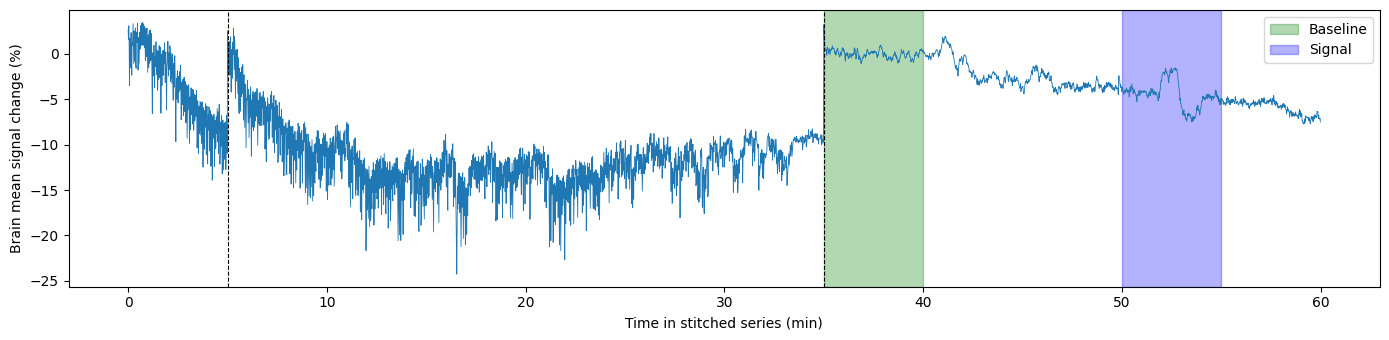

In [5]:
BIN_S = 30  # length of the bins that are tested against each other

base_start, sig_start, win = int(base_start_idx.value), int(sig_start_idx.value), int(win_idx.value)
base_end, sig_end = base_start + win, sig_start + win
if min(base_start, sig_start) < 0 or max(base_end, sig_end) > n_total:
    raise ValueError(f"Windows must lie within the stitched series (0-{n_total - 1}).")
if base_start < sig_end and sig_start < base_end:
    raise ValueError("Baseline and signal window overlap.")

bin_vols = max(1, int(round(BIN_S / tr)))
n_bins = win // bin_vols
if n_bins < 3:
    raise ValueError(f"Window of {win} volumes holds only {n_bins} bins of {BIN_S} s; increase the window or decrease BIN_S.")


def window_bins(x, start):
    """Mean of every non-overlapping bin of the window starting at `start` (last axis is time)."""
    seg = x[..., start:start + n_bins * bin_vols]
    return seg.reshape(*seg.shape[:-1], n_bins, bin_vols).mean(axis=-1)


def scan_boundaries():
    return [start for _, start, _ in scan_ranges[1:]]


def mark_windows(ax, to_time=lambda v: v * tr / 60):
    ax.axvspan(to_time(base_start), to_time(base_end), color="green", alpha=0.3, label="Baseline")
    ax.axvspan(to_time(sig_start), to_time(sig_end), color="blue", alpha=0.3, label="Signal")
    for b in scan_boundaries():
        ax.axvline(to_time(b), color="k", ls="--", lw=0.8)


print_statement(f"Baseline window: volumes {base_start}-{base_end - 1}; signal window: volumes {sig_start}-{sig_end - 1}; "
                f"{n_bins} bins of {bin_vols} volumes ({bin_vols * tr:.0f} s) each", bcolors.OKGREEN)

# Whole-brain mean as a check of the window choice (dashed lines = scan boundaries)
brain_base = window_bins(brain_ts, base_start).mean()
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(np.arange(n_total) * tr / 60, (brain_ts - brain_base) / brain_base * 100, lw=0.6)
mark_windows(ax)
ax.set_xlabel("Time in stitched series (min)")
ax.set_ylabel("Brain mean signal change (%)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Atlas Coregistration and Signal Change per Brain Region

Select the species in the widget cell below; it fills in the matching atlas:
- **Rat:** SIGMA in vivo template, rigid registration.
- **Mouse:** DSURQE (MICe) template. It is an ex vivo, whole-head average, so it is brain-masked, downsampled to 0.1 mm for registration, and registered with a scaling term and `nmi` cost. Any other mouse template/label pair (e.g. Allen CCFv3) can be entered instead.

The registration is the same as in `mol_fMRI_electric_stim_analysis.ipynb` and is stored in the same folder, `roi_atlas_<species>/`, so a registration that already exists is reused. The multi-label atlas is resampled once onto the functional grid with nearest-neighbour interpolation, so the functional data itself is never interpolated.

Then the mean time course of every atlas region (inside the brain mask) is extracted, and the signal window is compared with the baseline window (Welch t-test on the bins), with Benjamini-Hochberg FDR correction across regions. This replaces manually drawn ROIs. Outputs go to `roi_atlas_<species>/poststim/`:
- `poststim_roi_response.csv`: every region with baseline-normalised signal change, t, p and FDR-corrected q; `poststim_roi_responders.csv` lists only the regions with a significant increase.
- `poststim_roi_psc_timeseries_all.csv`: percent signal change time course of every region.
- `poststim_roi_response_map.nii.gz`: signal change of the responding regions on the functional grid.
- `plots/`: one figure per region (time course with both windows and the bin values); the responders are also in `plots/responders/`.

Optional label names CSV: either columns `id,name`, or the DSURQE / SIGMA structure lists with separate left and right label columns (regions then get an `_L` / `_R` suffix). Without it, regions are named `label_<id>`.

In [6]:
SPECIES_ATLAS = species_atlas_config(FMRI_ROOT)

atlas_layout = widgets.Layout(width="700px")
atlas_style = {"description_width": "160px"}
species_dropdown = widgets.Dropdown(options=list(SPECIES_ATLAS), value="rat", description="Species:", layout=widgets.Layout(width="280px"), style=atlas_style)
atlas_template_entered = widgets.Text(description="Atlas template:", layout=atlas_layout, style=atlas_style)
atlas_labels_entered = widgets.Text(description="Atlas labels:", layout=atlas_layout, style=atlas_style)
atlas_mask_entered = widgets.Text(placeholder="optional, restricts the template to the brain", description="Template brain mask:", layout=atlas_layout, style=atlas_style)
atlas_names_entered = widgets.Text(placeholder="optional CSV (id,name or left/right label columns)", description="Label names CSV:", layout=atlas_layout, style=atlas_style)


def fill_atlas_defaults(change=None):
    cfg = SPECIES_ATLAS[species_dropdown.value]
    atlas_template_entered.value = cfg["template"]
    atlas_labels_entered.value = cfg["labels"]
    atlas_mask_entered.value = cfg["mask"]
    atlas_names_entered.value = cfg["names"]


species_dropdown.observe(fill_atlas_defaults, names="value")
fill_atlas_defaults()

display(widgets.VBox([species_dropdown, atlas_template_entered, atlas_labels_entered, atlas_mask_entered, atlas_names_entered],
    layout=widgets.Layout(padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")))

In [7]:
OPEN_FSLEYES = True  # look at the registration / the maps in fsleyes

species = species_dropdown.value
species_cfg = SPECIES_ATLAS[species]
atlas_template = Path(atlas_template_entered.value.strip()).resolve()
atlas_labels = Path(atlas_labels_entered.value.strip()).resolve()
atlas_mask_text = atlas_mask_entered.value.strip()
for f in (atlas_template, atlas_labels) + ((Path(atlas_mask_text),) if atlas_mask_text else ()):
    if not f.is_file():
        raise FileNotFoundError(f"{f} (atlas files for {species} not found; check the paths above)")

atlas_dir = analysis_dir / f"roi_atlas_{species}"
atlas_dir.mkdir(exist_ok=True)
post_dir = atlas_dir / "poststim"
post_dir.mkdir(exist_ok=True)
func_reference = analysis_dir / "mean_mc_func.nii.gz"

print_header(f"Registering structural to functional and to the {species} atlas", bcolors.HEADER)
composite, labels_funcspace = register_to_atlas(Path(structural_file_for_coregistration), func_reference, atlas_dir, species_cfg,
                                                atlas_template, atlas_labels, atlas_mask_text)

# Check the registration visually before trusting the regions
if OPEN_FSLEYES:
    subprocess.run(["fsleyes", str(func_reference), str(labels_funcspace), "-cm", "random", "-a", "40"])


**************************************************************************************************************************************
                                     Registering structural to functional and to the mouse atlas                                      
**************************************************************************************************************************************

struct2func registration already exists. Skipping.
struct2atlas registration already exists. Skipping.
[COMMAND] cat_matvec -ONELINE /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/struct2func.matvec /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/struct2atlas.matvec -I
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii -m

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/atlas/DSURQE_mouse_atlas/DSURQE_40micron_labels.nii
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    4.032    6.125    3.082
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/atlas_labels_funcspace.nii.gz
++ 3dAllineate: total CPU time = 0.5 sec  Elapsed = 2.0
++ ###########################################################


[OK] Atlas labels in functional space: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/atlas_labels_funcspace.nii.gz


182 regions analysed, 20 with a significant signal increase (FDR q < 0.05)
 label_id                                             name  n_voxels     baseline  signal_psc          t            p        q_fdr  responder
      291                          Primary visual cortex_L         5 25329.839844  -13.802774 -32.688164 2.547367e-15 2.788241e-13      False
      295     Secondary visual cortex: mediolateral area_L        13 55187.687500  -14.472021 -24.568843 3.064001e-15 2.788241e-13      False
      300                         Ventral orbital cortex_L        11 17798.839844  -11.958831 -24.791291 3.419267e-14 2.074356e-12      False
      267                         Lateral orbital cortex_L         9 15310.111328  -20.129958 -20.424795 1.490297e-13 6.780851e-12      False
      163                         Ventral orbital cortex_R        37 18070.666016  -16.860467 -20.718199 2.945717e-13 1.072241e-11      False
       46                        Primary auditory cortex_R         8 7455

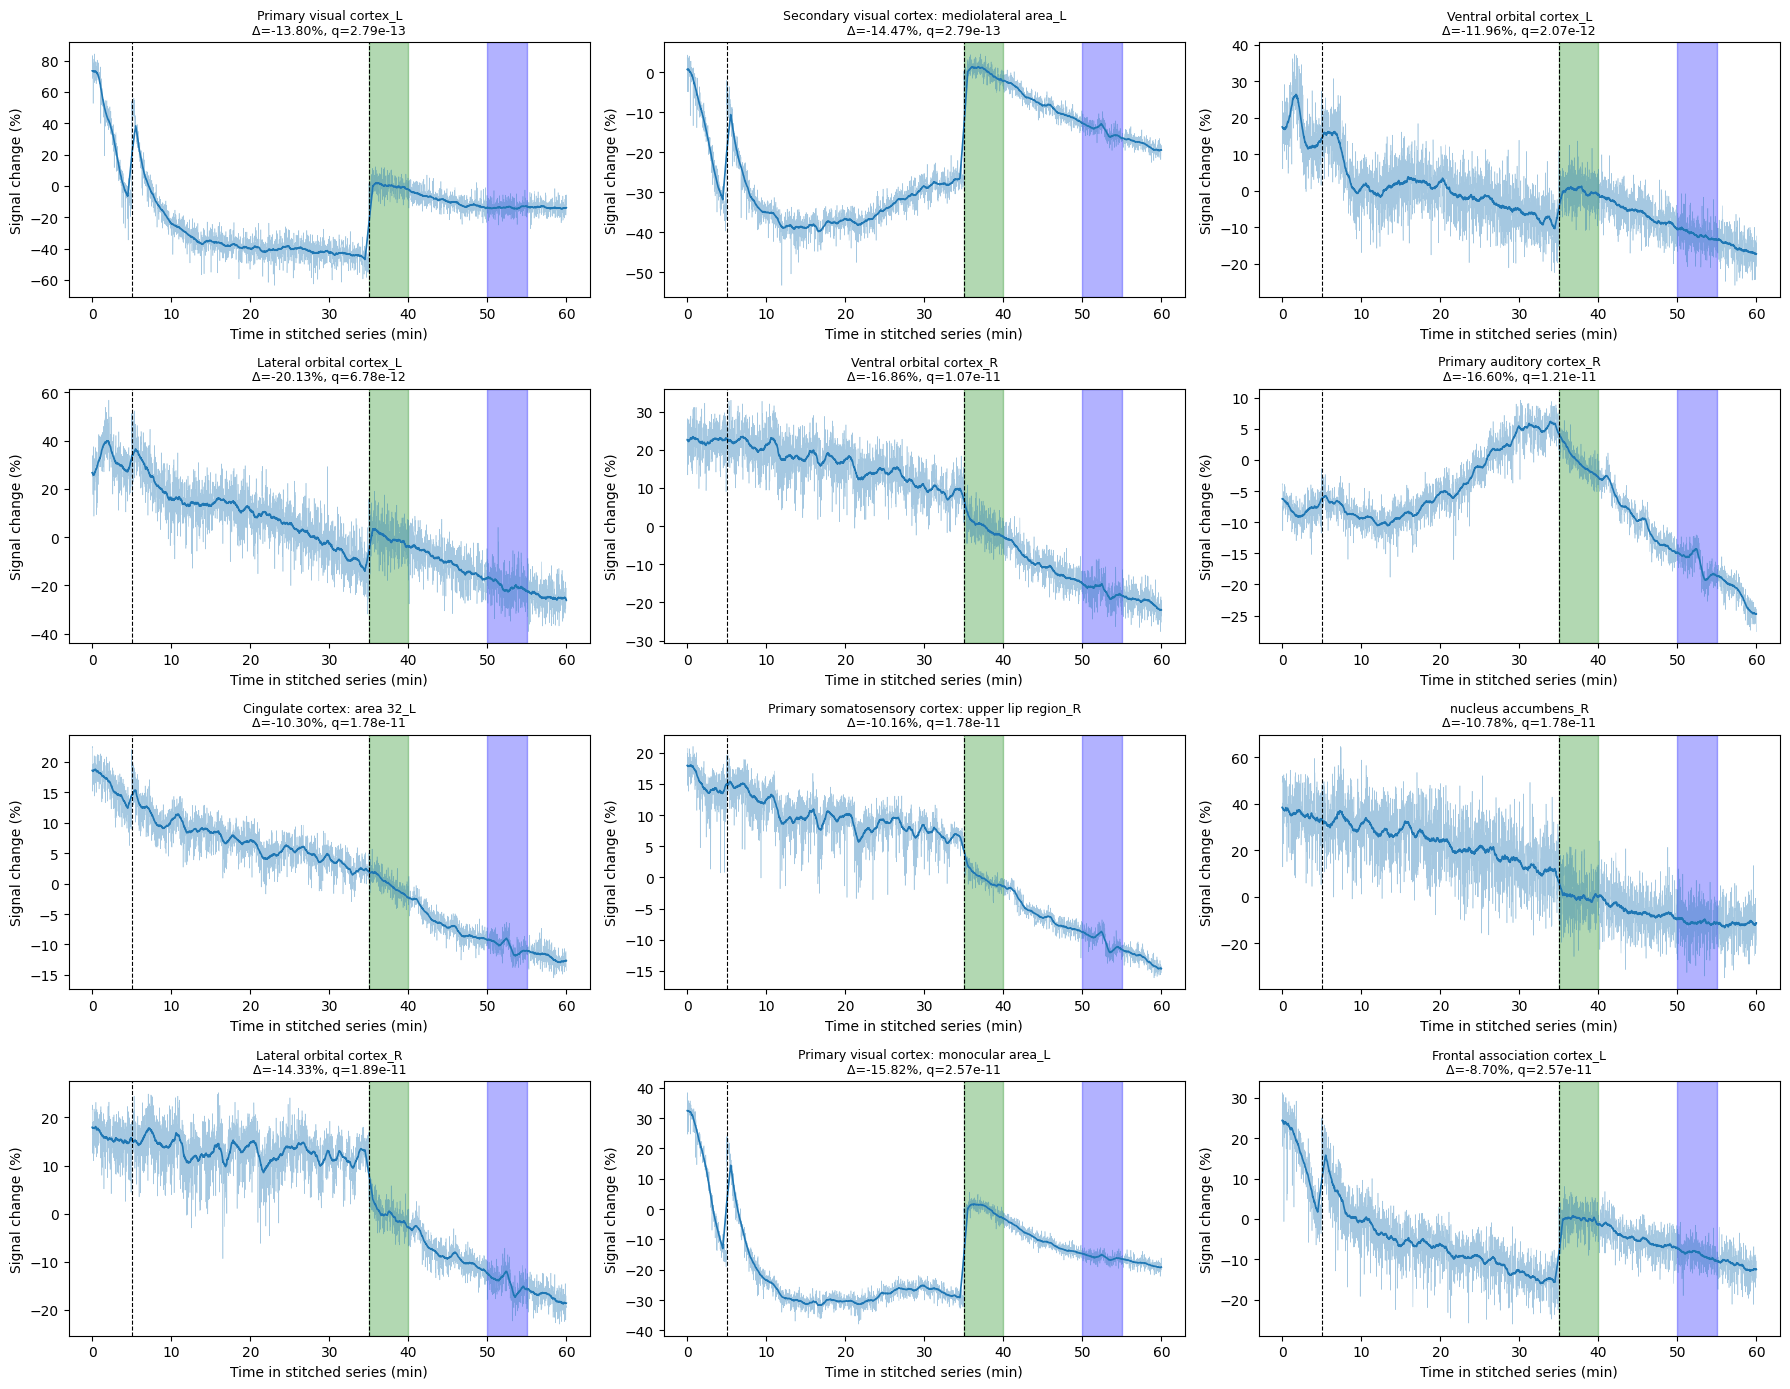

Figures saved in /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/plots (20 responders in /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/plots/responders)


In [8]:
from scipy import stats
from scipy.ndimage import uniform_filter1d
from statsmodels.stats.multitest import multipletests

MIN_VOXELS = 5
FDR_ALPHA = 0.05
N_PLOT = 12
PLOT_SMOOTH_S = 60  # smoothing of the plotted time courses
SAVE_ALL_REGION_PLOTS = True  # one figure per region in plots/ (responders always saved)

labels_img = nib.load(str(labels_funcspace))
labels = np.rint(labels_img.get_fdata()).astype(int)
if brain.shape != labels.shape:
    raise ValueError(f"Brain mask {brain.shape} and atlas labels {labels.shape} are on different grids.")
labels[~brain] = 0
label_names = load_label_names(atlas_names_entered.value.strip()) if atlas_names_entered.value.strip() else {}


def save_map(data, path):
    """Saves a map on the functional grid as float32 (the label image header would otherwise cast it to integers)."""
    header = labels_img.header.copy()
    header.set_data_dtype(np.float32)
    nib.save(nib.Nifti1Image(data.astype(np.float32), labels_img.affine, header), str(path))


smooth_vols = max(1, int(round(PLOT_SMOOTH_S / tr)))
t_min = np.arange(n_total) * tr / 60
plot_dir = post_dir / "plots"
(plot_dir / "responders").mkdir(parents=True, exist_ok=True)

rows, region_psc, region_bins = [], {}, {}
for lid in np.unique(labels[labels > 0]):
    sel = labels == lid
    n_vox = int(sel.sum())
    if n_vox < MIN_VOXELS:
        continue
    ts = func_4d[sel].mean(axis=0)
    b_bins, s_bins = window_bins(ts, base_start), window_bins(ts, sig_start)
    base = b_bins.mean()
    if base <= 0:
        continue
    t_stat, p_val = stats.ttest_ind(s_bins, b_bins, equal_var=False)
    name = label_names.get(int(lid), f"label_{lid}")
    region_psc[lid] = (ts - base) / base * 100
    region_bins[lid] = ((b_bins - base) / base * 100, (s_bins - base) / base * 100)
    rows.append({"label_id": int(lid), "name": name, "n_voxels": n_vox,
                 "baseline": base, "signal_psc": (s_bins.mean() - base) / base * 100, "t": t_stat, "p": p_val})

results = pd.DataFrame(rows)
valid = results["p"].notna()
results.loc[valid, "q_fdr"] = multipletests(results.loc[valid, "p"], alpha=FDR_ALPHA, method="fdr_bh")[1]
results = results.sort_values("p").reset_index(drop=True)
results["responder"] = (results["q_fdr"] < FDR_ALPHA) & (results["signal_psc"] > 0)

results.to_csv(post_dir / "poststim_roi_response.csv", index=False)
results[results["responder"]].to_csv(post_dir / "poststim_roi_responders.csv", index=False)
pd.DataFrame({results.loc[results.label_id == lid, "name"].iloc[0]: psc for lid, psc in region_psc.items()}).to_csv(
    post_dir / "poststim_roi_psc_timeseries_all.csv", index_label="volume")

print_statement(f"{len(results)} regions analysed, {int(results['responder'].sum())} with a significant signal increase (FDR q < {FDR_ALPHA})", bcolors.OKGREEN)
print(results.head(20).to_string(index=False))

# Map of the signal change in regions that respond
response_map = np.zeros(labels.shape, dtype=np.float32)
for r in results[results["responder"]].itertuples():
    response_map[labels == r.label_id] = r.signal_psc
save_map(response_map, post_dir / "poststim_roi_response_map.nii.gz")


def plot_time_course(ax, r, title_size=9):
    psc = region_psc[r.label_id]
    ax.plot(t_min, psc, lw=0.4, alpha=0.4)
    ax.plot(t_min, uniform_filter1d(psc, smooth_vols), lw=1.2, color="C0")
    mark_windows(ax)
    ax.set_xlabel("Time in stitched series (min)")
    ax.set_ylabel("Signal change (%)")
    ax.set_title(f"{r.name}\nΔ={r.signal_psc:.2f}%, q={r.q_fdr:.3g}", fontsize=title_size)


# Strongest regions
top = results.head(N_PLOT)
n_rows = int(np.ceil(len(top) / 3))
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 3.5 * n_rows), squeeze=False)
for ax, r in zip(axes.flat, top.itertuples()):
    plot_time_course(ax, r)
for ax in list(axes.flat)[len(top):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(post_dir / "poststim_roi_response_top_regions.svg", dpi=300)
plt.show()


def save_region_plot(r):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})
    plot_time_course(ax1, r, title_size=11)
    ax1.set_title(f"{r.name} ({r.n_voxels} voxels)")
    b, s = region_bins[r.label_id]
    ax2.boxplot([b, s], showfliers=False)
    for i, vals in enumerate((b, s), start=1):
        ax2.scatter(np.full(len(vals), i) + np.random.default_rng(0).uniform(-0.1, 0.1, len(vals)), vals, s=10, color="k", zorder=3)
    ax2.set_xticks([1, 2], ["Baseline", "Signal"])
    ax2.set_ylabel(f"Signal change (%), {BIN_S} s bins")
    ax2.set_title(f"t={r.t:.2f}, p={r.p:.3g}, q={r.q_fdr:.3g}")
    fig.tight_layout()
    fname = f"poststim_{r.label_id}_{safe_name(r.name)}.svg"
    if SAVE_ALL_REGION_PLOTS:
        fig.savefig(plot_dir / fname, dpi=300)
    if r.responder:
        fig.savefig(plot_dir / "responders" / fname, dpi=300)
    plt.close(fig)


for r in results.itertuples():
    if SAVE_ALL_REGION_PLOTS or r.responder:
        save_region_plot(r)
print_statement(f"Figures saved in {plot_dir} ({int(results['responder'].sum())} responders in {plot_dir / 'responders'})", bcolors.OKGREEN)

# Voxelwise Signal Change Maps in Atlas Space (for group analysis)

The region analysis above stays in native space, so the functional time series are never interpolated. For voxelwise group statistics, the maps are computed in native space and then moved to atlas space with the inverse of the functional → atlas matrix (struct2func and struct2atlas), in a single resampling step:
- `poststim_diff_psc`: mean signal-window minus baseline-window signal, in % of the baseline, per voxel (the signal change map of `mol_fMRI_v5.4.ipynb`).
- `poststim_tstat`: Welch t of the signal bins vs. the baseline bins per voxel.
- `mean_func` and `brain_mask`, for overlays and for restricting the group statistics to the brain.

The bin images are smoothed with a Gaussian kernel (`SMOOTH_FWHM_MM`, within the brain mask) before the maps are computed. Set it to 0 to switch smoothing off.

Outputs go to `roi_atlas_<species>/poststim/native_maps/` and `.../atlas_space/` (on the registration template grid, which is the same for every animal of the species). Region-wise group comparisons can use `poststim_roi_response.csv` directly, since the atlas labels already define the same regions in every animal.

In [10]:
from scipy.ndimage import gaussian_filter

SMOOTH_FWHM_MM = 0.3  # as in mol_fMRI_v5.4 (rat); 0 = no smoothing, probably smaller for mouse

zooms = np.array(labels_img.header.get_zooms()[:3], dtype=float)
sigma_vox = SMOOTH_FWHM_MM / 2.3548 / zooms
brain_f = brain.astype(np.float32)
brain_weight = gaussian_filter(brain_f, sigma_vox) if SMOOTH_FWHM_MM > 0 else brain_f


def smooth_in_brain(img):
    """Gaussian smoothing that does not pull in signal from outside the brain mask."""
    if SMOOTH_FWHM_MM <= 0:
        return img * brain_f
    return np.where(brain_weight > 0, gaussian_filter(img * brain_f, sigma_vox) / np.where(brain_weight > 0, brain_weight, 1), 0)


def smoothed_bins(start):
    bins = window_bins(func_4d, start)
    return np.stack([smooth_in_brain(bins[..., k]) for k in range(bins.shape[-1])], axis=-1)


base_bins, sig_bins = smoothed_bins(base_start), smoothed_bins(sig_start)
base_img = base_bins.mean(axis=-1)
valid_vox = brain & (base_img > 0)
diff_map = np.where(valid_vox, (sig_bins.mean(axis=-1) - base_img) / np.where(valid_vox, base_img, 1) * 100, 0)
with np.errstate(divide="ignore", invalid="ignore"):
    t_map = stats.ttest_ind(sig_bins, base_bins, axis=-1, equal_var=False).statistic
t_map = np.where(valid_vox, np.nan_to_num(t_map), 0)

native_maps = post_dir / "native_maps"
native_maps.mkdir(exist_ok=True)
for name, data in (("poststim_diff_psc", diff_map), ("poststim_tstat", t_map)):
    save_map(data, native_maps / f"{name}.nii.gz")

# Native -> atlas: inverse of the functional -> atlas matrix, resampled once onto the registration template grid
atlas_space = post_dir / "atlas_space"
atlas_space.mkdir(exist_ok=True)
atlas_grid = prepare_registration_template(atlas_template, atlas_mask_text, species_cfg["reg_voxel_mm"], atlas_dir)
native_to_atlas = atlas_dir / "native_to_atlas.aff12.1D"
res = run_afni(["cat_matvec", "-ONELINE", composite, "-I"], capture=True)
native_to_atlas.write_text(res.stdout.strip() + "\n")

for name, source, interp in (("poststim_diff_psc", native_maps / "poststim_diff_psc.nii.gz", "linear"),
                             ("poststim_tstat", native_maps / "poststim_tstat.nii.gz", "linear"),
                             ("mean_func", func_reference, "linear"),
                             ("brain_mask", mask_file, "NN")):
    run_afni(["3dAllineate", "-source", source, "-master", atlas_grid, "-1Dmatrix_apply", native_to_atlas,
              "-final", interp, "-prefix", atlas_space / f"{name}_atlasspace.nii.gz", "-overwrite"])
print_statement(f"[OK] Maps in atlas space: {atlas_space}", bcolors.OKGREEN)

# Check the alignment of the warped maps on the template
if OPEN_FSLEYES:
    subprocess.run(["fsleyes", str(atlas_grid), str(atlas_space / "poststim_tstat_atlasspace.nii.gz"), "-cm", "hot", "-dr", "2", "6"])

[COMMAND] cat_matvec -ONELINE /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/func_to_atlas_for_roi_apply.aff12.1D -I
[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/native_maps/poststim_diff_psc.nii.gz -master /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/template_registration_0.1mm.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/native_to_atlas.aff12.1D -final linear -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas

++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/native_maps/poststim_diff_psc.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    3.792    3.146    3.792
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/poststim_diff_psc_atlasspace.nii.gz
++ 3dAllineate: total CPU time = 0.1 sec  Elapsed = 0.3
++ ###########################################################
++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bi

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/native_maps/poststim_tstat.nii.gz -master /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/template_registration_0.1mm.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/native_to_atlas.aff12.1D -final linear -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/poststim_tstat_atlasspace.nii.gz -overwrite


++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/poststim_tstat_atlasspace.nii.gz
++ 3dAllineate: total CPU time = 0.1 sec  Elapsed = 0.2
++ ###########################################################
++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/mean_mc_func.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    3.792    3.146    3.792
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========


[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/mean_mc_func.nii.gz -master /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/template_registration_0.1mm.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/native_to_atlas.aff12.1D -final linear -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/mean_func_atlasspace.nii.gz -overwrite


++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/mean_func_atlasspace.nii.gz
++ 3dAllineate: total CPU time = 0.2 sec  Elapsed = 0.3
++ ###########################################################
++ 3dAllineate: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
++ Authored by: Zhark the Registrator
++ Source dataset: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/mask_mean_mc_func.nii.gz
++ Base dataset:   (not given)
++ Loading datasets into memory
 +        -cmass x y z shifts =    0.000    0.000    0.000
 +  shift search range is +/- =    3.792    3.146    3.792
++ OpenMP thread count = 11
++ ========== Applying transformation to 1 sub-bricks ==========
++ Output dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stit

[COMMAND] 3dAllineate -source /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/mask_mean_mc_func.nii.gz -master /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/template_registration_0.1mm.nii.gz -1Dmatrix_apply /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/native_to_atlas.aff12.1D -final NN -prefix /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space/brain_mask_atlasspace.nii.gz -overwrite
[OK] Maps in atlas space: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/roi_atlas_mouse/poststim/atlas_space
